In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


    Year  Average_Brent_Oil_Price
71  2017                    69.85
72  2018                    84.91
73  2019                    74.03
74  2020                    49.19
75  2021                    83.02
76  2022                   106.45
77  2023                    84.19
78  2024                    79.83
79  2025                    65.93
80  2026                    78.67


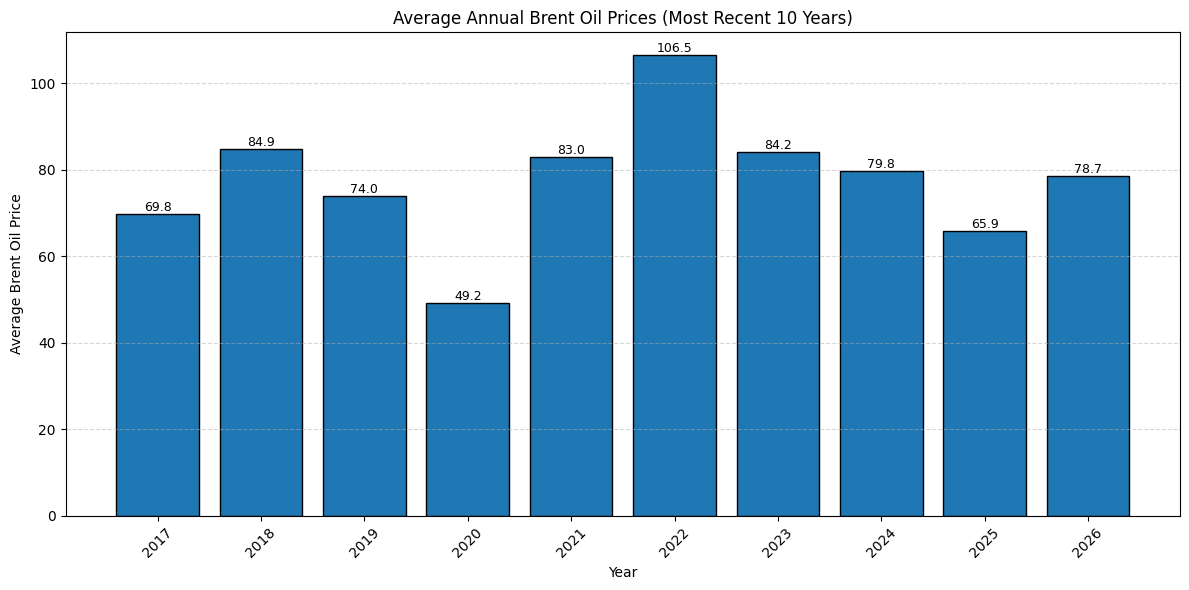

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

oil_df = pd.read_csv('/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv')

oil_df['Date'] = pd.to_datetime(oil_df['Date'], dayfirst=True)
oil_df['Year'] = oil_df['Date'].dt.year

annual_avg = (
    oil_df.groupby('Year')['Value']
    .mean()
    .reset_index()
)

annual_avg.columns = ['Year', 'Average_Brent_Oil_Price']

last_10_years = annual_avg.tail(10)

last_10_years.to_csv(
    'annual_brent_last10years.csv',
    index=False
)

print(last_10_years.round(2))

plt.figure(figsize=(12,6))

bars = plt.bar(
    last_10_years['Year'].astype(str),
    last_10_years['Average_Brent_Oil_Price'],
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Average Annual Brent Oil Prices (Most Recent 10 Years)')
plt.xlabel('Year')
plt.ylabel('Average Brent Oil Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    'average_brent_oil_last10years_bar_chart.pdf',
    bbox_inches='tight'
)

plt.show()